## b. Risk insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #to get the %

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
df_train = pd.read_csv('../data/train_clean.csv', index_col=0)

In [4]:
print(f"shape: {df_train.shape}  |  default rate: {df_train['SeriousDlqin2yrs'].mean():.2%}")

shape: (149998, 12)  |  default rate: 6.68%


In [5]:
baseline = df_train["SeriousDlqin2yrs"].mean()

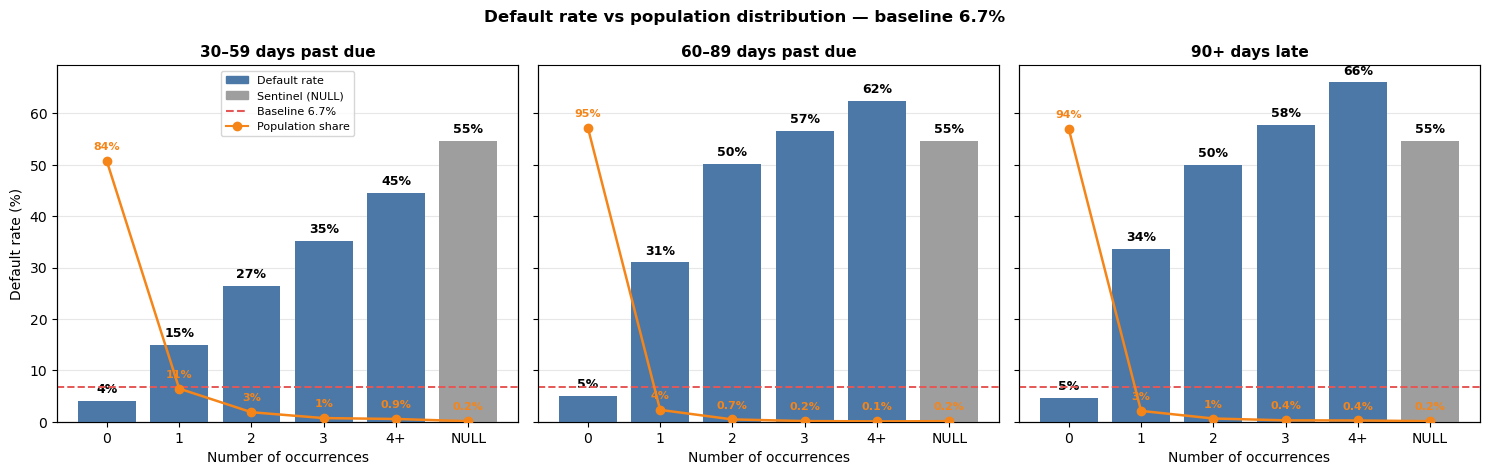

In [6]:
total = len(df_train)
order = ["0", "1", "2", "3", "4+", "NULL"]
labels_map = {0.0: "0", 1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4+"}
past_due_cols = [
    ("NumberOfTime30-59DaysPastDueNotWorse", "30–59 days past due"),
    ("NumberOfTime60-89DaysPastDueNotWorse", "60–89 days past due"),
    ("NumberOfTimes90DaysLate",              "90+ days late"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, (col, label) in zip(axes, past_due_cols):
    b = np.minimum(df_train[col], 4).map(labels_map).fillna("NULL")
    g = (df_train.groupby(b)["SeriousDlqin2yrs"]
         .agg(rate="mean", n="size").reindex(order).dropna())
    g["rate"] *= 100
    g["share"] = g["n"] / total * 100
    x = range(len(g))
    colors = ["#9E9E9E" if k == "NULL" else "#4C78A8" for k in g.index]
    bars = ax.bar(x, g["rate"], color=colors, zorder=3)
    ax.axhline(baseline * 100, color="#E45756", ls="--", lw=1.4, zorder=5)
    for bar, rate in zip(bars, g["rate"]):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 1, f"{rate:.0f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2 = ax.twinx()
    ax2.plot(x, g["share"], color="#F58518", marker="o", lw=1.8, zorder=4)
    for xi, s in zip(x, g["share"]):
        ax2.text(xi, s + 3, f"{s:.1f}%" if s < 1 else f"{s:.0f}%",
                 ha="center", va="bottom", fontsize=8, fontweight="bold", color="#F58518")
    ax2.set_ylim(0, 115)
    ax2.set_yticks([])
    ax2.grid(False)
    ax.set_xticks(list(x))
    ax.set_xticklabels(g.index)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Number of occurrences")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines["top"].set_visible(False)

axes[0].set_ylabel("Default rate (%)")
legend_items = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8"),
    plt.Rectangle((0, 0), 1, 1, color="#9E9E9E"),
    plt.Line2D([0], [0], color="#E45756", ls="--"),
    plt.Line2D([0], [0], color="#F58518", marker="o"),
]
axes[0].legend(legend_items,
               ["Default rate", "Sentinel (NULL)", f"Baseline {baseline:.1%}", "Population share"],
               fontsize=8, loc="upper center")
fig.suptitle(f"Default rate vs population distribution — baseline {baseline:.1%}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

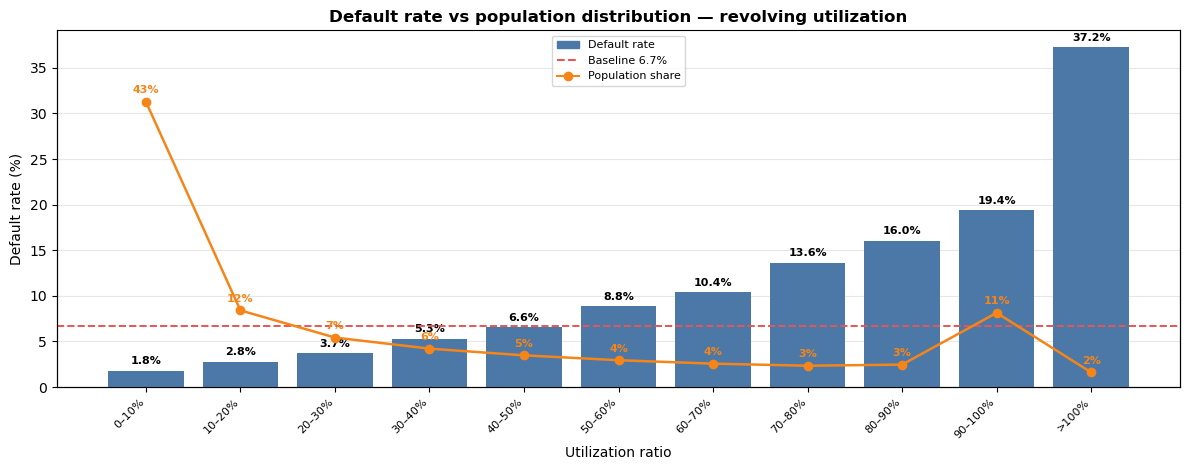

In [7]:
edges  = np.concatenate([[-0.01], np.arange(0.1, 1.01, 0.1), [np.inf]])
labels = ["0–10%", "10–20%", "20–30%", "30–40%", "40–50%",
          "50–60%", "60–70%", "70–80%", "80–90%", "90–100%", ">100%"]
util_bucket = pd.cut(df_train["RevolvingUtilizationOfUnsecuredLines"], bins=edges, labels=labels)

g = (df_train.groupby(util_bucket, observed=True)["SeriousDlqin2yrs"]
     .agg(rate="mean", n="size").reindex(labels).dropna())
g["rate"] *= 100
g["share"] = g["n"] / len(df_train) * 100
x = range(len(g))

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(x, g["rate"], color="#4C78A8", zorder=3)
ax.axhline(baseline * 100, color="#E45756", ls="--", lw=1.4, zorder=5)
for xi, rate in zip(x, g["rate"]):
    ax.text(xi, rate + 0.5, f"{rate:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")

ax2 = ax.twinx()
ax2.plot(x, g["share"], color="#F58518", marker="o", lw=1.8, zorder=4)
for xi, s in zip(x, g["share"]):
    ax2.text(xi, s + 1, f"{s:.0f}%", ha="center", va="bottom",
             fontsize=8, fontweight="bold", color="#F58518")
ax2.set_ylim(0, max(g["share"]) * 1.25)
ax2.set_yticks([])
ax2.grid(False)

ax.set_xticks(list(x))
ax.set_xticklabels(g.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Default rate vs population distribution — revolving utilization",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Utilization ratio")
ax.set_ylabel("Default rate (%)")
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)

legend_items = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8"),
    plt.Line2D([0], [0], color="#E45756", ls="--"),
    plt.Line2D([0], [0], color="#F58518", marker="o"),
]
ax.legend(legend_items, ["Default rate", f"Baseline {baseline:.1%}", "Population share"],
          fontsize=8, loc="upper center")

plt.tight_layout()
plt.show()

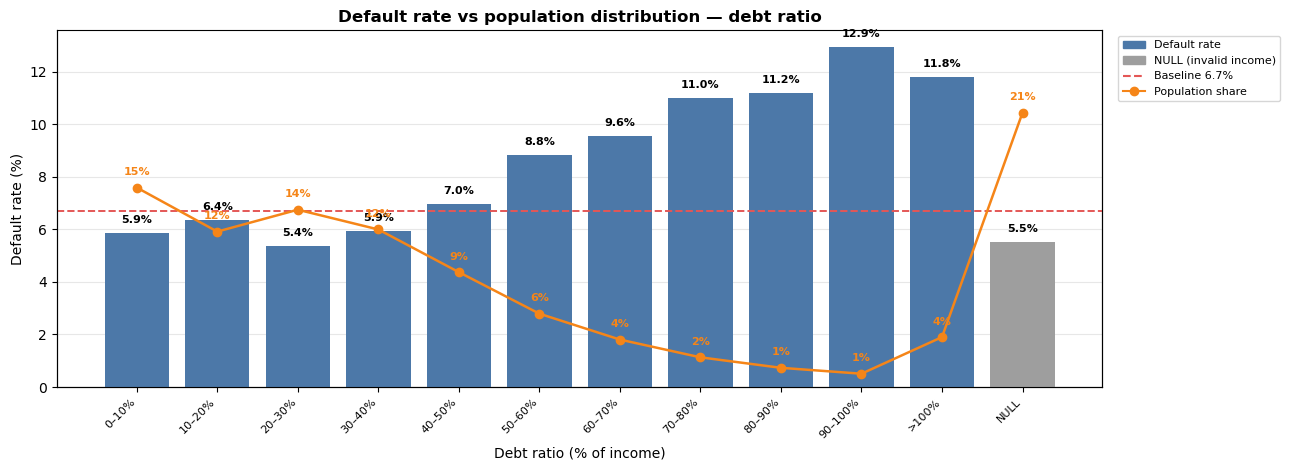

In [8]:
edges  = np.concatenate([[-0.01], np.arange(0.1, 1.01, 0.1), [np.inf]])
labels = ["0–10%", "10–20%", "20–30%", "30–40%", "40–50%",
          "50–60%", "60–70%", "70–80%", "80–90%", "90–100%", ">100%"]
b = pd.cut(df_train["DebtRatio"], bins=edges, labels=labels).astype("object").fillna("NULL")
order = labels + ["NULL"]

g = (df_train.groupby(b, observed=True)["SeriousDlqin2yrs"]
     .agg(rate="mean", n="size").reindex(order).dropna())
g["rate"] *= 100
g["share"] = g["n"] / len(df_train) * 100
x = range(len(g))

fig, ax = plt.subplots(figsize=(13, 4.8))
colors = ["#9E9E9E" if k == "NULL" else "#4C78A8" for k in g.index]
ax.bar(x, g["rate"], color=colors, zorder=3)
ax.axhline(baseline * 100, color="#E45756", ls="--", lw=1.4, zorder=5)
for xi, rate in zip(x, g["rate"]):
    ax.text(xi, rate + 0.3, f"{rate:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")

ax2 = ax.twinx()
ax2.plot(x, g["share"], color="#F58518", marker="o", lw=1.8, zorder=4)
for xi, s in zip(x, g["share"]):
    ax2.text(xi, s + 0.8, f"{s:.0f}%", ha="center", va="bottom",
             fontsize=8, fontweight="bold", color="#F58518")
ax2.set_ylim(0, max(g["share"]) * 1.3)
ax2.set_yticks([])
ax2.grid(False)

ax.set_xticks(list(x))
ax.set_xticklabels(g.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Default rate vs population distribution — debt ratio",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Debt ratio (% of income)")
ax.set_ylabel("Default rate (%)")
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)

legend_items = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8"),
    plt.Rectangle((0, 0), 1, 1, color="#9E9E9E"),
    plt.Line2D([0], [0], color="#E45756", ls="--"),
    plt.Line2D([0], [0], color="#F58518", marker="o"),
]
ax.legend(
    legend_items,
    ["Default rate", "NULL (invalid income)", f"Baseline {baseline:.1%}", "Population share"],
    fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1),
)

plt.tight_layout()
plt.show()

### Trying to explain the DebtRatio 2 peaks

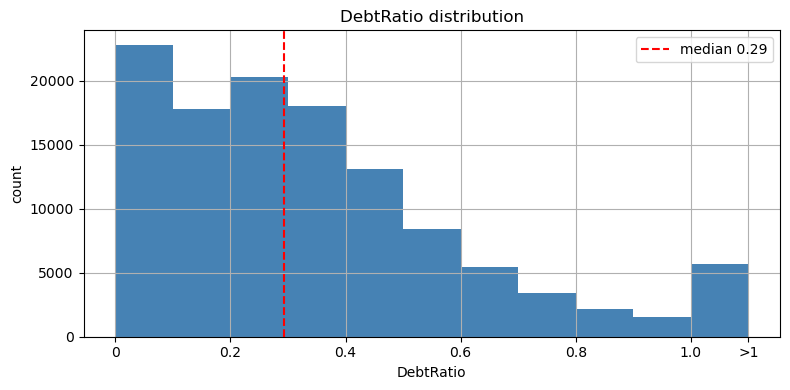

In [9]:
d = df_train['DebtRatio']
edges = np.append(np.arange(0, 1.01, 0.1), 1.1)   # 0.1 bins up to 1, then >1 aggregated

fig, ax = plt.subplots(figsize=(8, 4))
d.clip(upper=1.05).hist(bins=edges, ax=ax, color='steelblue')
ax.axvline(d.median(), color='red', ls='--', lw=1.5, label=f'median {d.median():.2f}')
ax.set_xticks(list(np.arange(0, 1.1, 0.2)) + [1.1])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0', '>1'])
ax.set_title('DebtRatio distribution')
ax.set_xlabel('DebtRatio')
ax.set_ylabel('count')
ax.legend()
plt.tight_layout()
plt.show()

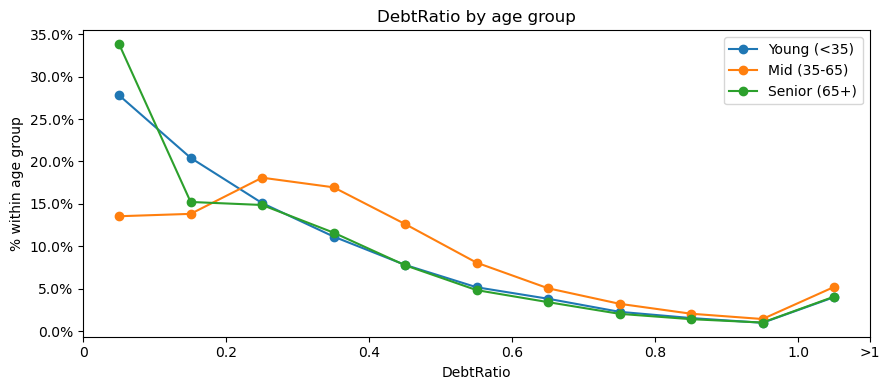

In [10]:
d = df_train.dropna(subset=['DebtRatio'])
edges = np.append(np.arange(0, 1.01, 0.1), 1.1)
centers = (edges[:-1] + edges[1:]) / 2
groups = {
    'Young (<35)':  d.loc[d['age'] < 35, 'DebtRatio'].clip(upper=1.05),
    'Mid (35-65)':  d.loc[(d['age'] >= 35) & (d['age'] < 65), 'DebtRatio'].clip(upper=1.05),
    'Senior (65+)': d.loc[d['age'] >= 65, 'DebtRatio'].clip(upper=1.05),
}
fig, ax = plt.subplots(figsize=(9, 4))
for name, s in groups.items():
    counts, _ = np.histogram(s, bins=edges)
    pct = counts / counts.sum() * 100          # % within each age group
    ax.plot(centers, pct, marker='o', label=name)
ax.set_xticks(list(np.arange(0, 1.1, 0.2)) + [1.1])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0', '>1'])
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('DebtRatio by age group')
ax.set_xlabel('DebtRatio')
ax.set_ylabel('% within age group')
ax.legend()
plt.tight_layout()
plt.show()

## Population attributes

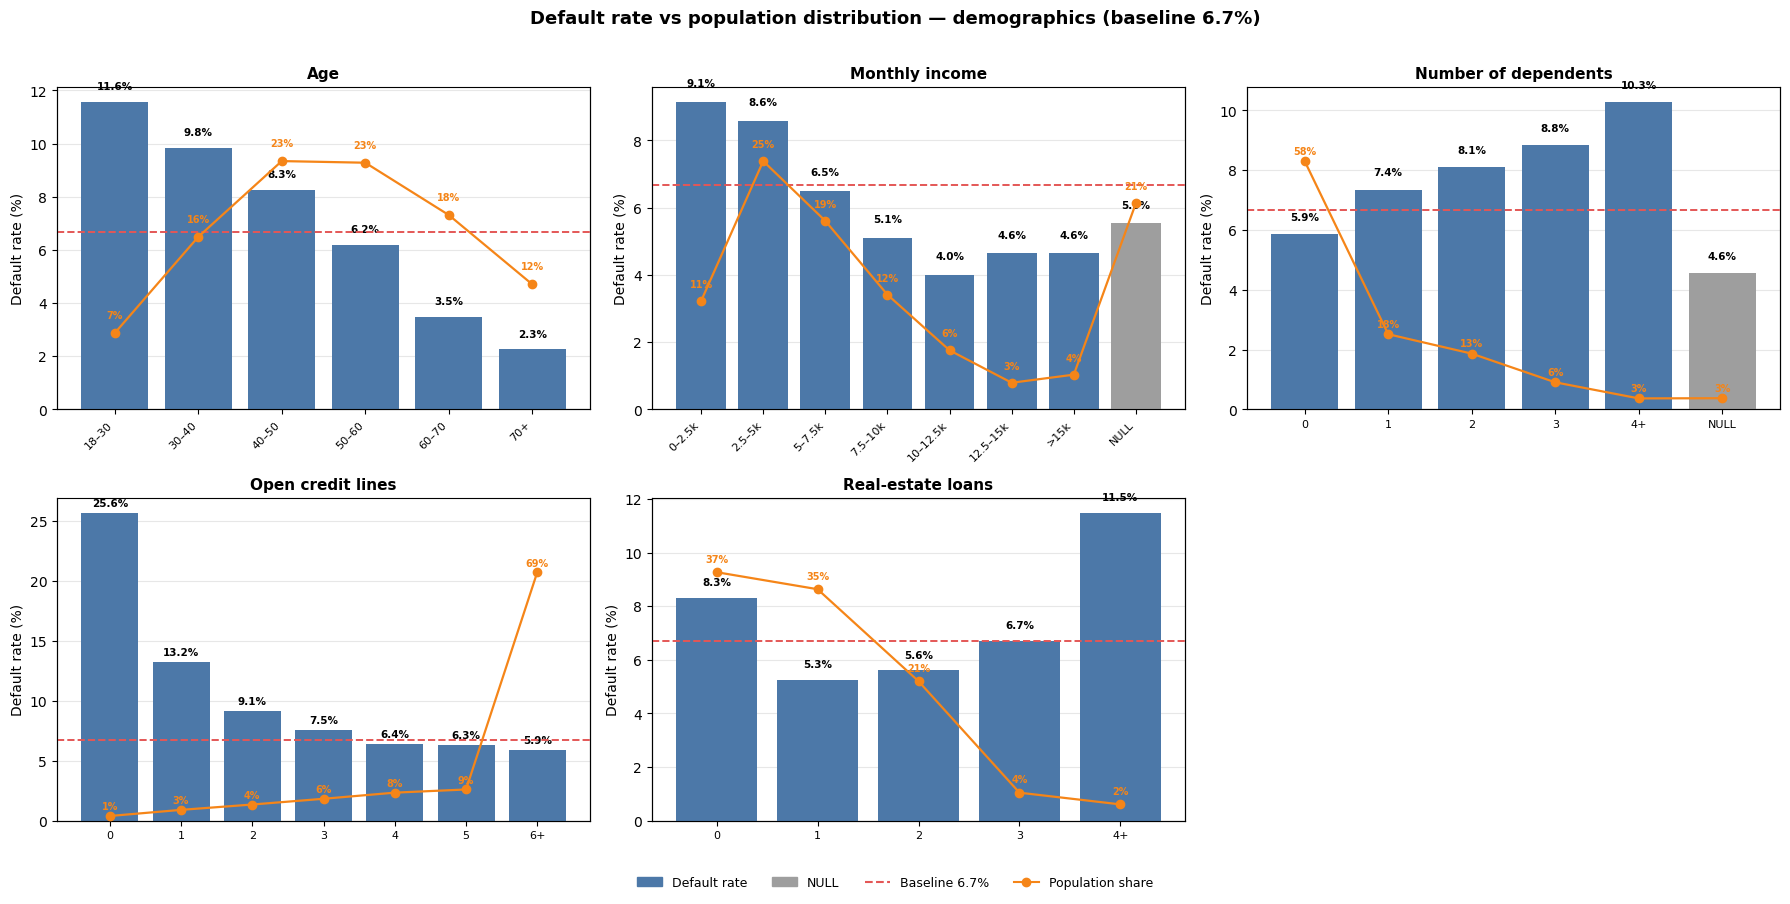

In [11]:
total = len(df_train)
panels = [
    dict(col="age", title="Age", kind="cut",
         edges=[18, 30, 40, 50, 60, 70, np.inf],
         labels=["18–30", "30–40", "40–50", "50–60", "60–70", "70+"]),
    dict(col="MonthlyIncome", title="Monthly income", kind="cut",
         edges=[0.0, 2500, 5000, 7500, 10000, 12500, 15000, np.inf],
         labels=["0–2.5k", "2.5–5k", "5–7.5k", "7.5–10k", "10–12.5k", "12.5–15k", ">15k"]),
    dict(col="NumberOfDependents", title="Number of dependents", kind="cap", cap=4, null=True),
    dict(col="NumberOfOpenCreditLinesAndLoans", title="Open credit lines", kind="cap", cap=6, null=False),
    dict(col="NumberRealEstateLoansOrLines", title="Real-estate loans", kind="cap", cap=4, null=False),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes_flat = axes.ravel()
for p, ax in zip(panels, axes_flat):
    s = df_train[p["col"]]
    if p["kind"] == "cut":
        is_null = s.isna() | (s == 0)
        b = pd.cut(s.where(~is_null), bins=p["edges"], labels=p["labels"]).astype("object")
        b[is_null] = "NULL"; order = p["labels"] + ["NULL"]; rot = 45
    else:
        cap = p["cap"]; lab = [str(i) for i in range(cap)] + [f"{cap}+"]
        b = pd.cut(np.minimum(s, cap), bins=np.arange(-0.5, cap + 1, 1), labels=lab).astype("object")
        if p["null"]:
            b[s.isna()] = "NULL"; order = lab + ["NULL"]
        else:
            order = lab
        rot = 0
    g = (df_train.groupby(b, observed=True)["SeriousDlqin2yrs"]
         .agg(rate="mean", n="size").reindex(order).dropna())
    g["rate"] *= 100; g["share"] = g["n"] / total * 100; x = range(len(g))
    colors = ["#9E9E9E" if k == "NULL" else "#4C78A8" for k in g.index]
    ax.bar(x, g["rate"], color=colors, zorder=3)
    ax.axhline(baseline * 100, color="#E45756", ls="--", lw=1.4, zorder=5)
    for xi, rate in zip(x, g["rate"]):
        ax.text(xi, rate + 0.4, f"{rate:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
    ax2 = ax.twinx(); ax2.plot(x, g["share"], color="#F58518", marker="o", lw=1.6, zorder=4)
    for xi, sh in zip(x, g["share"]):
        ax2.text(xi, sh + 1.2, f"{sh:.0f}%", ha="center", va="bottom",
                 fontsize=7, fontweight="bold", color="#F58518")
    ax2.set_ylim(0, max(g["share"]) * 1.3); ax2.set_yticks([]); ax2.grid(False)
    ax.set_xticks(list(x)); ax.set_xticklabels(g.index, rotation=rot, ha="right" if rot else "center", fontsize=8)
    ax.set_title(p["title"], fontsize=11, fontweight="bold"); ax.set_ylabel("Default rate (%)")
    ax.grid(axis="y", alpha=0.3, zorder=0); ax.spines["top"].set_visible(False)
for ax in axes_flat[len(panels):]:
    ax.set_visible(False)
legend_items = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8"), plt.Rectangle((0, 0), 1, 1, color="#9E9E9E"),
    plt.Line2D([0], [0], color="#E45756", ls="--"), plt.Line2D([0], [0], color="#F58518", marker="o"),
]
fig.legend(legend_items, ["Default rate", "NULL", f"Baseline {baseline:.1%}", "Population share"],
           fontsize=9, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle(f"Default rate vs population distribution — demographics (baseline {baseline:.1%})",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

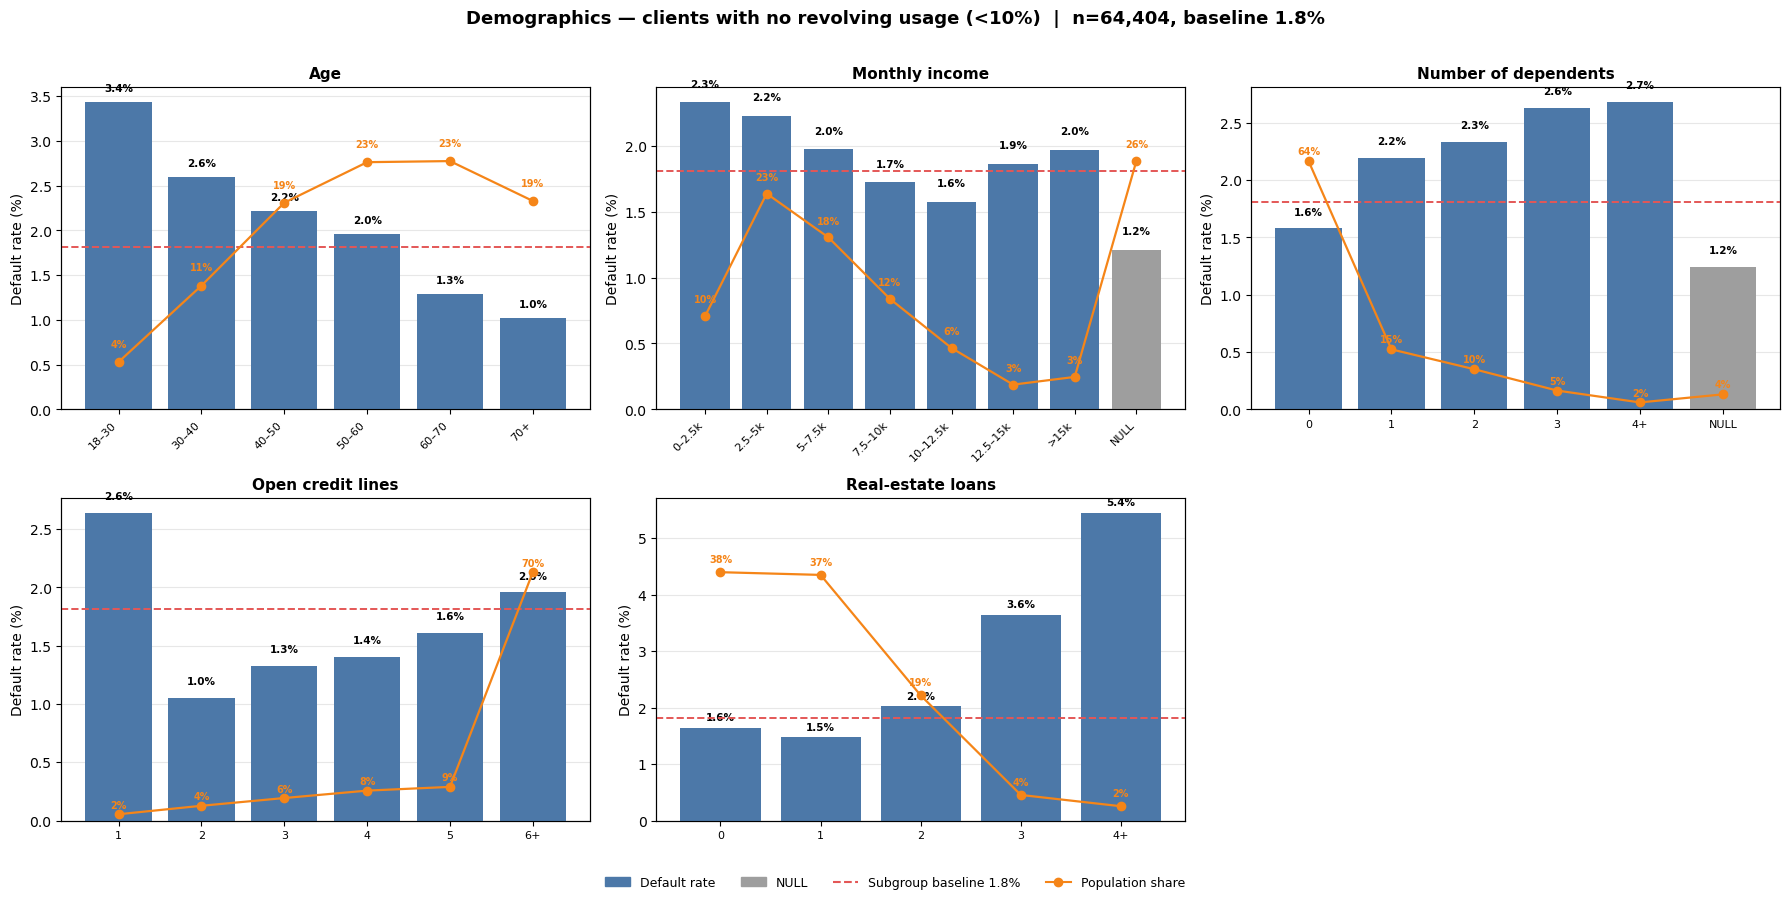

In [12]:
sub = df_train[df_train["RevolvingUtilizationOfUnsecuredLines"] < 0.1]
sub_baseline = sub["SeriousDlqin2yrs"].mean()
total = len(sub)
panels = [
    dict(col="age", title="Age", kind="cut",
         edges=[18, 30, 40, 50, 60, 70, np.inf],
         labels=["18–30", "30–40", "40–50", "50–60", "60–70", "70+"]),
    dict(col="MonthlyIncome", title="Monthly income", kind="cut",
         edges=[0.0, 2500, 5000, 7500, 10000, 12500, 15000, np.inf],
         labels=["0–2.5k", "2.5–5k", "5–7.5k", "7.5–10k", "10–12.5k", "12.5–15k", ">15k"]),
    dict(col="NumberOfDependents", title="Number of dependents", kind="cap", cap=4, null=True),
    dict(col="NumberOfOpenCreditLinesAndLoans", title="Open credit lines", kind="cap", cap=6, null=False),
    dict(col="NumberRealEstateLoansOrLines", title="Real-estate loans", kind="cap", cap=4, null=False),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes_flat = axes.ravel()
for p, ax in zip(panels, axes_flat):
    s = sub[p["col"]]
    if p["kind"] == "cut":
        is_null = s.isna() | (s == 0)
        b = pd.cut(s.where(~is_null), bins=p["edges"], labels=p["labels"]).astype("object")
        b[is_null] = "NULL"; order = p["labels"] + ["NULL"]; rot = 45
    else:
        cap = p["cap"]; lab = [str(i) for i in range(cap)] + [f"{cap}+"]
        b = pd.cut(np.minimum(s, cap), bins=np.arange(-0.5, cap + 1, 1), labels=lab).astype("object")
        if p["null"]:
            b[s.isna()] = "NULL"; order = lab + ["NULL"]
        else:
            order = lab
        rot = 0
    g = (sub.groupby(b, observed=True)["SeriousDlqin2yrs"]
         .agg(rate="mean", n="size").reindex(order).dropna())
    g["rate"] *= 100; g["share"] = g["n"] / total * 100; x = range(len(g))
    colors = ["#9E9E9E" if k == "NULL" else "#4C78A8" for k in g.index]
    ax.bar(x, g["rate"], color=colors, zorder=3)
    ax.axhline(sub_baseline * 100, color="#E45756", ls="--", lw=1.4, zorder=5)
    for xi, rate in zip(x, g["rate"]):
        ax.text(xi, rate + 0.1, f"{rate:.1f}%", ha="center", va="bottom", fontsize=7.5, fontweight="bold")
    ax2 = ax.twinx(); ax2.plot(x, g["share"], color="#F58518", marker="o", lw=1.6, zorder=4)
    for xi, sh in zip(x, g["share"]):
        ax2.text(xi, sh + 1.2, f"{sh:.0f}%", ha="center", va="bottom",
                 fontsize=7, fontweight="bold", color="#F58518")
    ax2.set_ylim(0, max(g["share"]) * 1.3); ax2.set_yticks([]); ax2.grid(False)
    ax.set_xticks(list(x)); ax.set_xticklabels(g.index, rotation=rot, ha="right" if rot else "center", fontsize=8)
    ax.set_title(p["title"], fontsize=11, fontweight="bold"); ax.set_ylabel("Default rate (%)")
    ax.grid(axis="y", alpha=0.3, zorder=0); ax.spines["top"].set_visible(False)
for ax in axes_flat[len(panels):]:
    ax.set_visible(False)
legend_items = [
    plt.Rectangle((0, 0), 1, 1, color="#4C78A8"), plt.Rectangle((0, 0), 1, 1, color="#9E9E9E"),
    plt.Line2D([0], [0], color="#E45756", ls="--"), plt.Line2D([0], [0], color="#F58518", marker="o"),
]
fig.legend(legend_items, ["Default rate", "NULL", f"Subgroup baseline {sub_baseline:.1%}", "Population share"],
           fontsize=9, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle(f"Demographics — clients with no revolving usage (<10%)  |  n={total:,}, baseline {sub_baseline:.1%}",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()